# De la donnée brute à la décision : analyser, visualiser, prédire
## Étude de cas - Plateforme e-commerce TogoShop (Togo)

**Formation :** Machine Learning - Projet final
**Formateur :** Pape Ibrahima Niang, Data Science & IA - Dakar, Sénégal
**Dataset :** `ecommerce_togo.csv` (~3 000 commandes)
**Notation :** /100 · **Durée estimée :** 15–20 h

---

## 1. Contexte

**TogoShop** est une plateforme de commerce en ligne basée à Lomé, livrant dans tout le pays (Sokodé, Kara, Kpalimé, Atakpamé, Dapaong…). L'entreprise dispose d'un historique de commandes qu'elle n'exploite pas encore.

En tant que **Data Analyst / Data Scientist junior**, ma mission est de transformer ces données brutes en informations exploitables, puis en modèles prédictifs au service de la décision métier.

## 2. Problématiques métier

La direction attend des réponses concrètes à trois questions :

1. **Comprendre** - Qui sont nos clients, que commandent-ils, où, et qu'est-ce qui influence le montant d'une commande ?
2. **Anticiper la satisfaction** - Peut-on prédire si un client sera satisfait afin d'agir avant qu'il ne soit déçu ?
3. **Segmenter** - Peut-on regrouper les clients en profils homogènes pour personnaliser les offres ?

## 3. Objectifs pédagogiques évalués

Ce projet mobilise l'ensemble des compétences de la formation :

- **Analyse exploratoire (EDA)** - nettoyage des données, statistiques descriptives, détection d'anomalies et de corrélations.
- **Visualisation** - graphiques pertinents avec `matplotlib` et `seaborn`, ainsi qu'au moins un graphique interactif avec `Plotly`.
- **Apprentissage automatique** - une régression, une classification et un clustering, correctement évalués (métriques, validation).
- **Restitution** - synthèse claire des résultats et recommandations métier actionnables.

## 4. Plan du notebook

1. Contexte et mission *(cette section)*
2. Chargement et inspection du jeu de données
3. Nettoyage et préparation des données
4. Analyse exploratoire (EDA)
5. Visualisations (matplotlib, seaborn, Plotly)
6. Modélisation - Régression *(prédiction du montant de commande)*
7. Modélisation - Classification *(prédiction de la satisfaction client)*
8. Modélisation - Clustering *(segmentation client)*
9. Synthèse des résultats et recommandations métier


*Auteur(s) : A. Katy Gracia EKOUE*
*Date : 01 Juillet 2026*


## Partie A - Préparation et analyse exploratoire

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pio.renderers.default = "notebook_connected"


In [92]:
# Imports complémentaires pour la classification et le clustering
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    silhouette_score
)

In [46]:
df = pd.read_csv('ecommerce_togo.csv')
print(f"Dimensions du dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes")
df.head()

Dimensions du dataset : 3015 lignes x 22 colonnes


,id_commande,id_client,ville,categorie,canal_achat,mode_paiement,age_client,genre,anciennete_client_jours,client_premium,...,remise_pct,frais_livraison_fcfa,montant_total_fcfa,mois,jour_semaine,delai_livraison_jours,retard_livraison,satisfaction_1_5,satisfait,retour_produit
0,CMD200000,CLI11125,Dapaong,Alimentaire,Site web,Mobile Money,48.0,F,NaN,1,...,18.9,4336,7538,8,Dim,5.4,1,4,1,0
1,CMD200001,CLI11372,Lomé,Mode,Site web,Mobile Money,20.0,H,NaN,0,...,0.0,1717,77029,9,Sam,NaN,0,4,1,0
2,CMD200002,CLI11679,Kpalimé,Alimentaire,Application mobile,Espèces à la livraison,26.0,H,159.0,1,...,12.6,1888,53502,10,Ven,2.8,0,4,1,0
3,CMD200003,CLI10473,Kpalimé,Téléphonie,Application mobile,Espèces à la livraison,NaN,F,453.0,0,...,NaN,2563,143686,11,Jeu,3.3,0,3,0,0
4,CMD200004,CLI11353,Dapaong,Mode,Application mobile,Espèces à la livraison,42.0,H,503.0,0,...,0.0,3388,54914,2,Jeu,7.4,1,3,0,0


In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3015 entries, 0 to 3014
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_commande              3015 non-null   str    
 1   id_client                3015 non-null   str    
 2   ville                    3015 non-null   str    
 3   categorie                3015 non-null   str    
 4   canal_achat              3015 non-null   str    
 5   mode_paiement            3015 non-null   str    
 6   age_client               2894 non-null   float64
 7   genre                    3015 non-null   str    
 8   anciennete_client_jours  2954 non-null   float64
 9   client_premium           3015 non-null   int64  
 10  quantite                 3015 non-null   int64  
 11  prix_unitaire_fcfa       3015 non-null   int64  
 12  remise_pct               2925 non-null   float64
 13  frais_livraison_fcfa     3015 non-null   int64  
 14  montant_total_fcfa       3015 non-n

In [48]:
df.describe()

,age_client,anciennete_client_jours,client_premium,quantite,prix_unitaire_fcfa,remise_pct,frais_livraison_fcfa,montant_total_fcfa,mois,delai_livraison_jours,retard_livraison,satisfaction_1_5,satisfait,retour_produit
count,2894.000000,2954.00000,3015.000000,3015.000000,3015.000000,2925.000000,3015.000000,3.015000e+03,3015.000000,2864.000000,3015.000000,3015.000000,3015.000000,3015.000000
mean,32.464064,388.75220,0.215920,2.586070,24305.539635,4.154120,2181.041791,6.271208e+04,6.478939,3.101641,0.123051,4.063350,0.815257,0.045108
std,8.649766,386.23314,0.411528,1.266617,24797.405738,5.548568,793.892632,7.690576e+04,3.435558,1.593929,0.328551,0.683705,0.388153,0.207575
min,18.000000,1.00000,0.000000,1.000000,1500.000000,0.000000,500.000000,2.607000e+03,1.000000,0.500000,0.000000,2.000000,0.000000,0.000000
25%,26.000000,109.25000,0.000000,2.000000,7866.000000,0.000000,1553.000000,1.727100e+04,4.000000,1.900000,0.000000,4.000000,1.000000,0.000000
50%,32.000000,261.50000,0.000000,2.000000,15299.000000,0.000000,2060.000000,3.689500e+04,6.000000,3.000000,0.000000,4.000000,1.000000,0.000000
75%,38.000000,547.75000,0.000000,3.000000,31351.000000,7.700000,2757.500000,7.626350e+04,10.000000,4.200000,0.000000,5.000000,1.000000,0.000000
max,62.000000,2200.00000,1.000000,9.000000,169428.000000,20.000000,4877.000000,1.058746e+06,12.000000,8.600000,1.000000,5.000000,1.000000,1.000000


In [49]:
doublons = df.duplicated().sum()
print(f"Nombre de doublons détectés : {doublons}")

df = df.drop_duplicates()
print(f"Nombre de lignes après suppression des doublons : {df.shape[0]}")

df['id_commande'].isnull().sum()

Nombre de doublons détectés : 15
Nombre de lignes après suppression des doublons : 3000


np.int64(0)

In [50]:
valeurs_manquantes = df.isna().sum()
valeurs_manquantes = valeurs_manquantes[valeurs_manquantes > 0]
pct_manquant = (valeurs_manquantes / len(df) * 100).round(2)
pd.DataFrame({'nb_manquants': valeurs_manquantes, 'pct_manquant': pct_manquant}).sort_values('nb_manquants', ascending=False)

,nb_manquants,pct_manquant
delai_livraison_jours,150,5.0
age_client,120,4.0
remise_pct,90,3.0
anciennete_client_jours,60,2.0


In [51]:
# Traitement des valeurs manquantes (imputation, cf. justification ci-dessus)

# age_client et anciennete_client_jours : variables numériques, on impute par la médiane
# (plus robuste que la moyenne si la distribution est asymétrique ou contient des valeurs extrêmes)
df['age_client'] = df['age_client'].fillna(df['age_client'].median())
df['anciennete_client_jours'] = df['anciennete_client_jours'].fillna(df['anciennete_client_jours'].median())

# delai_livraison_jours : idem, imputation par la médiane
df['delai_livraison_jours'] = df['delai_livraison_jours'].fillna(df['delai_livraison_jours'].median())

# remise_pct : une valeur manquante signifie très probablement qu'aucune remise n'a été appliquée -> imputation par 0
df['remise_pct'] = df['remise_pct'].fillna(0)

# Vérification : il ne doit plus rester de valeurs manquantes
print("Valeurs manquantes restantes :", df.isna().sum().sum())

Valeurs manquantes restantes : 0


### Statistiques descriptives des variables clés

In [52]:
df[['montant_total_fcfa', 'quantite', 'age_client', 'delai_livraison_jours', 'satisfaction_1_5']].describe()

,montant_total_fcfa,quantite,age_client,delai_livraison_jours,satisfaction_1_5
count,3.000000e+03,3000.00000,3000.000000,3000.000000,3000.000000
mean,6.283048e+04,2.58600,32.440000,3.099767,4.062333
std,7.706497e+04,1.26773,8.473744,1.553105,0.684059
min,2.607000e+03,1.00000,18.000000,0.500000,2.000000
25%,1.722800e+04,2.00000,26.000000,2.000000,4.000000
50%,3.692500e+04,2.00000,32.000000,3.000000,4.000000
75%,7.641925e+04,3.00000,38.000000,4.125000,5.000000
max,1.058746e+06,9.00000,62.000000,8.600000,5.000000


### Constat 1 - Catégorie la plus rentable

In [53]:
r_categorie = df.groupby('categorie').agg(
    quantite_total=('quantite', 'sum'),
    prix_total=('montant_total_fcfa', 'sum'),
    nb_commandes=('id_commande', 'count'),
    taux_retour=('retour_produit', 'mean'),
    satisfaction_moyenne=('satisfaction_1_5', 'mean')
).sort_values(by='prix_total', ascending=False)

r_categorie

,quantite_total,prix_total,nb_commandes,taux_retour,satisfaction_moyenne
categorie,,,,,
Téléphonie,976,56602323,382,0.052356,4.068063
Électronique,1268,54111889,483,0.031056,4.082816
Mode,2040,30914784,776,0.055412,4.027062
Maison,1230,27478511,477,0.041929,4.079665
Beauté,1004,9907159,397,0.040302,4.070529
Alimentaire,1240,9476766,485,0.043299,4.070103


On normalise ces indicateurs (0 à 1) pour construire un score composite par catégorie et identifier la plus performante globalement (volume, CA, faible taux de retour, satisfaction).

In [54]:
colonnes = [
    'quantite_total',
    'prix_total',
    'nb_commandes',
    'taux_retour',
    'satisfaction_moyenne'
]

df_norm = r_categorie.copy()
min_vals = r_categorie[colonnes].min()
max_vals = r_categorie[colonnes].max()
df_norm[colonnes] = (r_categorie[colonnes] - min_vals) / (max_vals - min_vals)

df_norm

,quantite_total,prix_total,nb_commandes,taux_retour,satisfaction_moyenne
categorie,,,,,
Téléphonie,0.000000,1.000000,0.000000,0.874516,0.735392
Électronique,0.274436,0.947153,0.256345,0.000000,1.000000
Mode,1.000000,0.454913,1.000000,1.000000,0.000000
Maison,0.238722,0.381995,0.241117,0.446404,0.943481
Beauté,0.026316,0.009133,0.038071,0.379627,0.779625
Alimentaire,0.248120,0.000000,0.261421,0.502662,0.771986


In [55]:
df_norm['Score'] = df_norm[colonnes].mean(axis=1)

df_norm = df_norm.sort_values(by='Score', ascending=False)
df_norm

,quantite_total,prix_total,nb_commandes,taux_retour,satisfaction_moyenne,Score
categorie,,,,,,
Mode,1.000000,0.454913,1.000000,1.000000,0.000000,0.690983
Téléphonie,0.000000,1.000000,0.000000,0.874516,0.735392,0.521982
Électronique,0.274436,0.947153,0.256345,0.000000,1.000000,0.495587
Maison,0.238722,0.381995,0.241117,0.446404,0.943481,0.450344
Alimentaire,0.248120,0.000000,0.261421,0.502662,0.771986,0.356838
Beauté,0.026316,0.009133,0.038071,0.379627,0.779625,0.246554


**Constat :** la catégorie en tête du score composite est la plus rentable globalement (meilleur équilibre entre chiffre d'affaires, volume de commandes, faible taux de retour et satisfaction). La catégorie *Mode* génère le plus de commandes, tandis que *Électronique* génère le chiffre d'affaires le plus élevé par commande.

In [56]:
print(f"Montant maximum d'une commande : {df['montant_total_fcfa'].max():,.0f} FCFA")
print(f"Montant minimum d'une commande : {df['montant_total_fcfa'].min():,.0f} FCFA")

Montant maximum d'une commande : 1,058,746 FCFA
Montant minimum d'une commande : 2,607 FCFA


### Constat 2 - Ville la plus active

In [57]:
r_ville = df.groupby('ville').agg(
    nb_commandes=('id_commande', 'count'),
    chiffre_affaires=('montant_total_fcfa', 'sum')
).sort_values(by='nb_commandes', ascending=False).reset_index()

r_ville

,ville,nb_commandes,chiffre_affaires
0,Lomé,1616,101470997
1,Sokodé,376,22188146
2,Kara,338,24655159
3,Kpalimé,283,16865246
4,Atakpamé,233,14683491
5,Dapaong,154,8628393


**Constat :** Lome, la ville en tête du tableau ci-dessus est la plus active, en nombre de commandes comme en chiffre d'affaires généré.

### Constat 3 - Impact du retard de livraison sur la satisfaction

In [58]:
df.groupby('retard_livraison')[['satisfaction_1_5', 'satisfait']].mean()

,satisfaction_1_5,satisfait
retard_livraison,,
0,4.116730,0.839924
1,3.675676,0.635135


**Constat :** les commandes livrées en retard (`retard_livraison = 1`) ont une note de satisfaction moyenne et un taux de clients satisfaits nettement plus faibles que les commandes livrées à temps. Le retard de livraison est un facteur clé d'insatisfaction pour TogoShop.

Produisez des visualisations soignées (titres, axes légendés, couleurs lisibles). Vous devez utiliser les trois bibliothèques :
Avec matplotlib

–	Un histogramme de la distribution des montants de commande.

–	Une série temporelle : évolution du chiffre d’affaires par mois.

Avec seaborn

–	Une heatmap des corrélations entre variables numériques.

–	Un boxplot du montant par catégorie de produit (ou de la satisfaction par retard).

Avec Plotly (interactif)

–	Au moins un graphique interactif (ex. carte/bar chart du CA par ville, ou nuage de points montant × délai colorié par satisfaction).


(array([2.384e+03, 3.910e+02, 1.420e+02, 4.300e+01, 2.400e+01, 1.000e+01,
        4.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([   2607.        ,   90618.58333333,  178630.16666667,
         266641.75      ,  354653.33333333,  442664.91666667,
         530676.5       ,  618688.08333333,  706699.66666667,
         794711.25      ,  882722.83333333,  970734.41666667,
        1058746.        ]),
 <BarContainer object of 12 artists>)

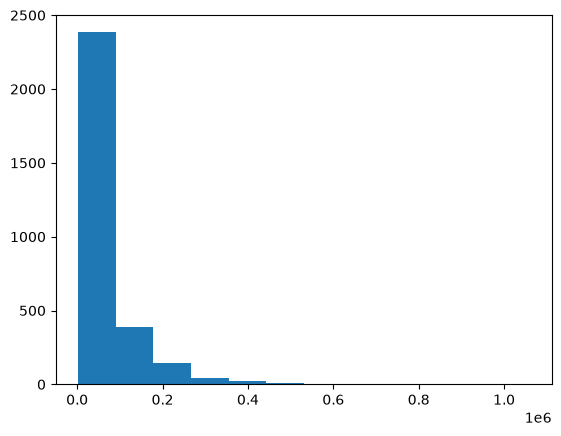

In [59]:
bins = int(np.log2(len(df)) + 1)

plt.hist(df['montant_total_fcfa'], bins=bins)

In [60]:
df_groupby_mois = df.groupby('mois')['montant_total_fcfa'].sum().reset_index()
df_groupby_mois

,mois,montant_total_fcfa
0,1,16192745
1,2,15061887
2,3,15140048
3,4,17840620
4,5,14710666
5,6,15388931
6,7,16512586
7,8,14666090
8,9,14268717
9,10,16949702


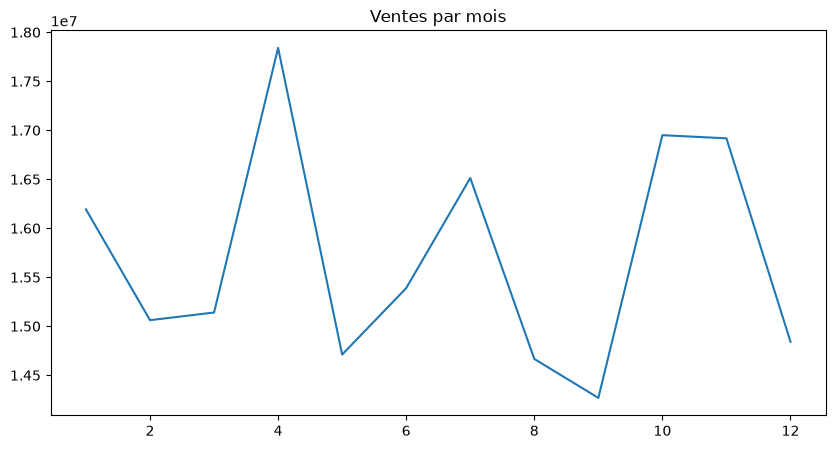

In [61]:
plt.figure(figsize=(10,5))
plt.plot(df_groupby_mois['mois'], df_groupby_mois['montant_total_fcfa'])
plt.title("Ventes par mois")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

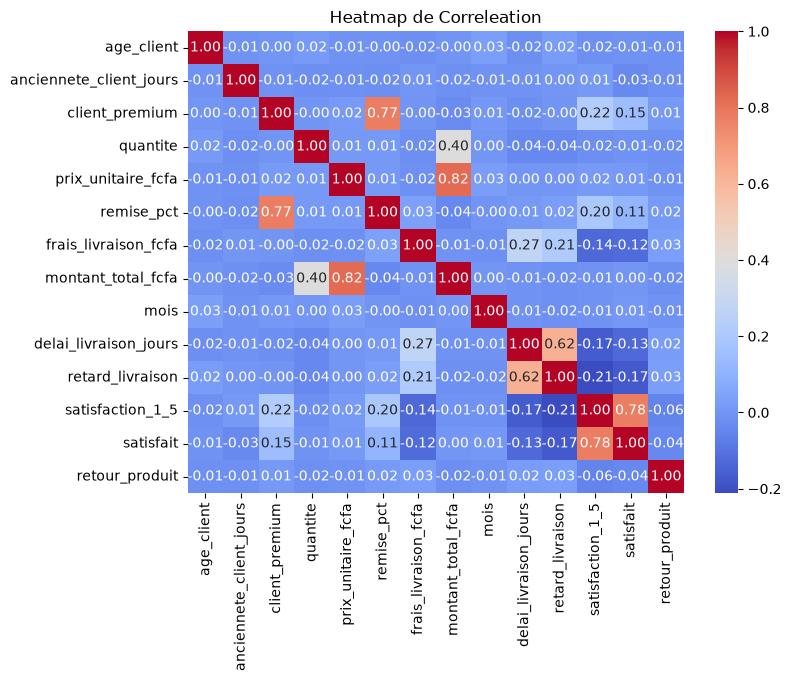

In [62]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot= True, cmap= 'coolwarm', fmt= '.2f')
plt.title('Heatmap de Correleation')
plt.show

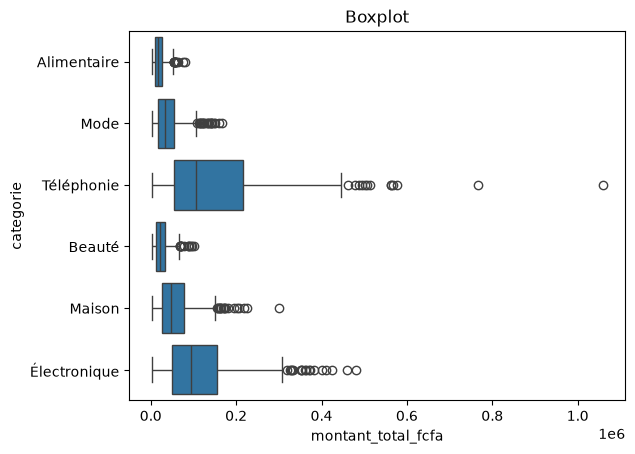

In [63]:
sns.boxplot(data=df, x= 'montant_total_fcfa', y= 'categorie')
plt.title('Boxplot')
plt.show()

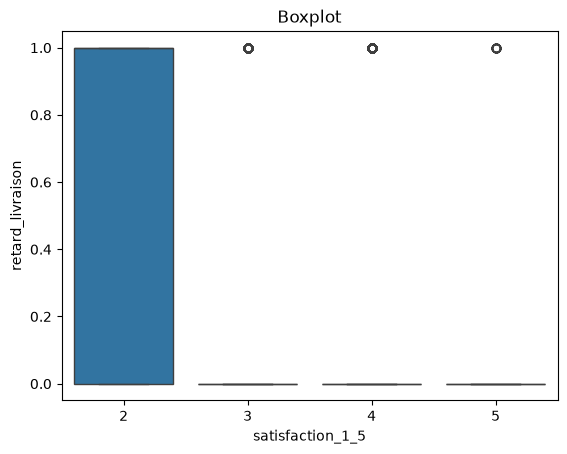

In [64]:
sns.boxplot(data=df, x= 'satisfaction_1_5', y= 'retard_livraison')
plt.title('Boxplot')
plt.show()

In [65]:
fig = px.bar(r_ville, x= 'ville', y= 'chiffre_affaires', color= 'chiffre_affaires')
fig.show()

In [66]:
fig= px.scatter(df, x='montant_total_fcfa', y='delai_livraison_jours', color= 'satisfaction_1_5')
fig.show()

## Partie B - Modélisation : Régression

**Question métier (1) :** qu'est-ce qui influence le montant d'une commande ?

**Cible :** `montant_total_fcfa` (variable continue) → **régression**.

> **Remarque méthodologique importante.** Les colonnes `quantite` et `prix_unitaire_fcfa` sont volontairement exclues des variables explicatives. En effet, `montant_total_fcfa` se déduit directement et exactement de ces colonnes (`montant = quantité × prix_unitaire × (1 − remise) + frais_livraison`) : les inclure donnerait un modèle avec un R² proche de 1 par pur calcul arithmétique, sans aucune valeur prédictive réelle (c'est une fuite de donnée / *data leakage*). On préfère ici prédire le montant à partir du **profil client et du contexte de la commande** (ville, canal d'achat, ancienneté, délai de livraison...) - une question bien plus utile pour le métier : *quels types de clients/contextes génèrent les commandes les plus élevées ?*

In [67]:
y = df['montant_total_fcfa']
X = df.drop(columns=['montant_total_fcfa', 'id_commande', 'id_client', 'satisfaction_1_5', 'quantite', 'prix_unitaire_fcfa'])

X.columns.tolist()

['ville',
 'categorie',
 'canal_achat',
 'mode_paiement',
 'age_client',
 'genre',
 'anciennete_client_jours',
 'client_premium',
 'remise_pct',
 'frais_livraison_fcfa',
 'mois',
 'jour_semaine',
 'delai_livraison_jours',
 'retard_livraison',
 'satisfait',
 'retour_produit']

### Séparation entraînement / test

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train : {X_train.shape[0]} commandes | Test : {X_test.shape[0]} commandes")

Train : 2400 commandes | Test : 600 commandes


### Prétraitement

On sépare les variables **numériques** (imputation par la médiane + standardisation) des variables **catégorielles** (imputation par le mode + encodage one-hot), assemblées dans un `ColumnTransformer` pour garantir un pipeline reproductible et sans fuite entre train et test.

In [69]:
colonnes_numeriques = ['age_client', 'anciennete_client_jours', 'client_premium', 'remise_pct',
                       'frais_livraison_fcfa', 'mois', 'delai_livraison_jours', 'retard_livraison',
                       'satisfait', 'retour_produit']
colonnes_categorielles = ['ville', 'categorie', 'canal_achat', 'mode_paiement', 'genre', 'jour_semaine']

transformer_numerique = Pipeline(steps=[
    ('imputation', SimpleImputer(strategy='median')),
    ('scaling', StandardScaler())
])
transformer_categoriel = Pipeline(steps=[
    ('imputation', SimpleImputer(strategy='most_frequent')),
    ('encodage', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_reg = ColumnTransformer(transformers=[
    ('num', transformer_numerique, colonnes_numeriques),
    ('cat', transformer_categoriel, colonnes_categorielles)
])

### Entraînement de deux modèles

In [70]:
modele_lineaire = Pipeline(steps=[
    ('preprocessing', preprocessor_reg),
    ('regressor', LinearRegression())
])
modele_lineaire.fit(X_train, y_train)

modele_random = Pipeline(steps=[
    ('preprocessing', preprocessor_reg),
    ('regressor', RandomForestRegressor(n_estimators=300, random_state=42))
])
modele_random.fit(X_train, y_train)

print("Modèles entraînés.")

Modèles entraînés.


### Évaluation et comparaison des modèles

In [71]:
def evaluer_regression(modele, nom, X_test, y_test):
    y_pred = modele.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return {'Modèle': nom, 'MAE (FCFA)': round(mae, 0), 'RMSE (FCFA)': round(rmse, 0), 'R²': round(r2, 3)}

resultats_reg = pd.DataFrame([
    evaluer_regression(modele_lineaire, 'Régression linéaire', X_test, y_test),
    evaluer_regression(modele_random, 'Random Forest', X_test, y_test)
])
resultats_reg

,Modèle,MAE (FCFA),RMSE (FCFA),R²
0,Régression linéaire,38915.0,59354.0,0.308
1,Random Forest,41187.0,62842.0,0.224


C:\Users\A. Katy Gracia EKOUE\AppData\Local\Temp\ipykernel_9680\2527658984.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resultats_reg, x='Modèle', y='R²', palette='viridis')


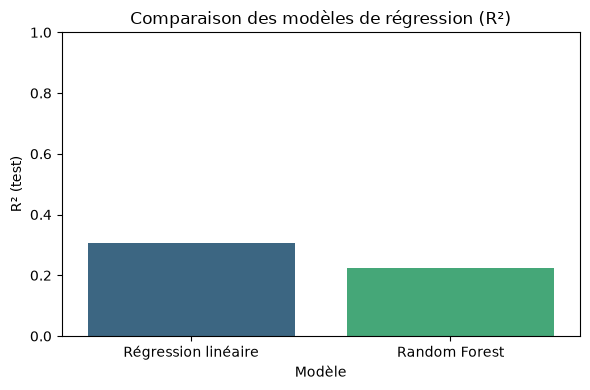

In [72]:
plt.figure(figsize=(6, 4))
sns.barplot(data=resultats_reg, x='Modèle', y='R²', palette='viridis')
plt.ylim(0, 1)
plt.title("Comparaison des modèles de régression (R²)")
plt.ylabel("R² (test)")
plt.tight_layout()
plt.show()

### Importance des variables (Random Forest)

C:\Users\A. Katy Gracia EKOUE\AppData\Local\Temp\ipykernel_9680\1155532814.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x='importance', y='variable', palette='mako')


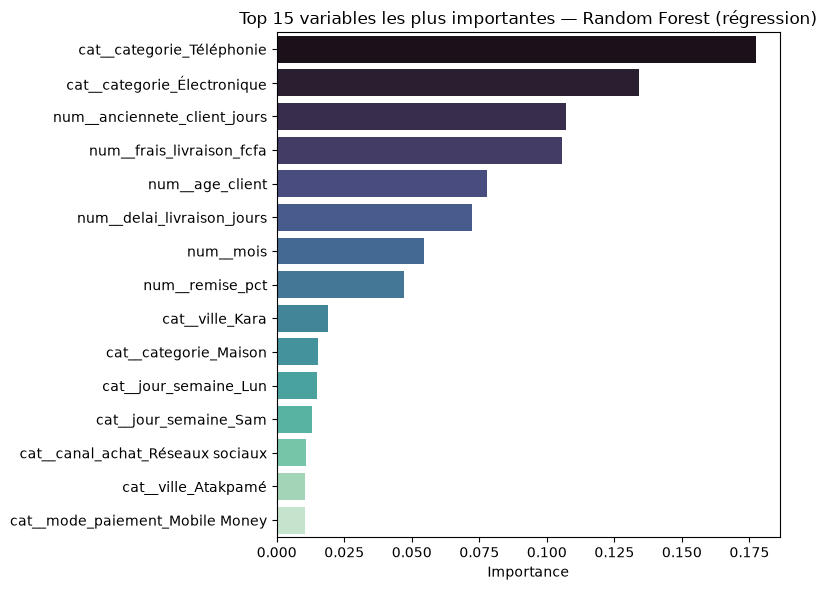

In [73]:
noms_variables = modele_random.named_steps['preprocessing'].get_feature_names_out()
importances = modele_random.named_steps['regressor'].feature_importances_

imp_df = pd.DataFrame({'variable': noms_variables, 'importance': importances}) \
            .sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df, x='importance', y='variable', palette='mako')
plt.title("Top 15 variables les plus importantes — Random Forest (régression)")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Interprétation (régression) :**

- La **régression linéaire** (R² = 0,308 · MAE ≈ 38 915 FCFA · RMSE ≈ 59 354 FCFA) obtient un score légèrement meilleur que le **Random Forest** (R² = 0,224 · MAE ≈ 41 187 FCFA). Une relation globalement linéaire suffit donc à capter l'essentiel du signal disponible dans ces variables, et le Random Forest n'apporte pas de valeur ajoutée ici (il a même tendance à sur-apprendre sur des variables catégorielles à nombreuses modalités).
- Avec un R² de ~0,31, le modèle explique environ **31 % de la variance** du montant des commandes à partir du seul profil client et du contexte (hors quantité/prix, volontairement exclus — voir remarque plus haut). Ce n'est pas énorme, mais c'est cohérent : le montant dépend surtout du produit précis acheté (que l'on n'observe pas ici en détail) et d'une part de hasard, plus que du profil du client.
- Les variables les plus influentes sont la **catégorie de produit** (Téléphonie et Électronique génèrent des paniers nettement plus élevés que les autres catégories), l'**ancienneté du client**, les **frais de livraison** et le **délai de livraison**.
- **Recommandation métier :** miser sur la mise en avant des catégories à forte valeur (Téléphonie, Électronique) dans les campagnes marketing, et suivre l'ancienneté client comme signal de valeur croissante (programme de fidélité progressif).

## Partie C - Modélisation : Classification

**Question métier (2) :** peut-on prédire si un client sera satisfait afin d'agir avant qu'il ne soit déçu ?

**Cible :** `satisfait` (0 = non satisfait, 1 = satisfait) → variable binaire → **classification**.

> **Attention à la fuite de donnée.** `satisfaction_1_5` est la note brute dont `satisfait` est directement dérivé (ex. satisfait = 1 si note ≥ 4) : on l'exclut absolument des variables explicatives, sinon le modèle "trichersait" en lisant quasiment la réponse. On exclut aussi `satisfait` lui-même (c'est la cible) et les identifiants, qui n'ont aucun pouvoir prédictif.

In [74]:
print("Répartition de la cible (satisfait) :")
print(df['satisfait'].value_counts(normalize=True).round(3))

y_clf = df['satisfait']
X_clf = df.drop(columns=['satisfait', 'satisfaction_1_5', 'id_commande', 'id_client'])

X_clf.columns.tolist()

Répartition de la cible (satisfait) :
satisfait
1    0.815
0    0.185
Name: proportion, dtype: float64


['ville',
 'categorie',
 'canal_achat',
 'mode_paiement',
 'age_client',
 'genre',
 'anciennete_client_jours',
 'client_premium',
 'quantite',
 'prix_unitaire_fcfa',
 'remise_pct',
 'frais_livraison_fcfa',
 'montant_total_fcfa',
 'mois',
 'jour_semaine',
 'delai_livraison_jours',
 'retard_livraison',
 'retour_produit']

### Séparation entraînement / test

On utilise `stratify=y_clf` pour conserver la même proportion de clients satisfaits/non satisfaits dans le train et le test - important car les classes ne sont pas forcément équilibrées.

In [75]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
print(f"Train : {X_train_c.shape[0]} commandes | Test : {X_test_c.shape[0]} commandes")

Train : 2400 commandes | Test : 600 commandes


### Prétraitement

In [76]:
colonnes_numeriques_c = ['age_client', 'anciennete_client_jours', 'client_premium', 'quantite',
                         'prix_unitaire_fcfa', 'remise_pct', 'frais_livraison_fcfa',
                         'montant_total_fcfa', 'mois', 'delai_livraison_jours',
                         'retard_livraison', 'retour_produit']
colonnes_categorielles_c = ['ville', 'categorie', 'canal_achat', 'mode_paiement', 'genre', 'jour_semaine']

preprocessor_clf = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputation', SimpleImputer(strategy='median')),
                       ('scaling', StandardScaler())]), colonnes_numeriques_c),
    ('cat', Pipeline([('imputation', SimpleImputer(strategy='most_frequent')),
                       ('encodage', OneHotEncoder(handle_unknown='ignore'))]), colonnes_categorielles_c)
])

### Entraînement de deux modèles

In [77]:
modele_logit = Pipeline(steps=[
    ('preprocessing', preprocessor_clf),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
modele_logit.fit(X_train_c, y_train_c)

modele_rf_clf = Pipeline(steps=[
    ('preprocessing', preprocessor_clf),
    ('classifier', RandomForestClassifier(n_estimators=300, random_state=42))
])
modele_rf_clf.fit(X_train_c, y_train_c)

print("Modèles entraînés.")

Modèles entraînés.


### Évaluation et comparaison des modèles

L'accuracy seule peut être trompeuse si les classes sont déséquilibrées : on regarde aussi précision, rappel et F1-score.

In [78]:
def evaluer_classification(modele, nom, X_test, y_test):
    y_pred = modele.predict(X_test)
    return {
        'Modèle': nom,
        'Accuracy': round(accuracy_score(y_test, y_pred), 3),
        'Précision': round(precision_score(y_test, y_pred), 3),
        'Rappel': round(recall_score(y_test, y_pred), 3),
        'F1-score': round(f1_score(y_test, y_pred), 3)
    }

resultats_clf = pd.DataFrame([
    evaluer_classification(modele_logit, 'Régression logistique', X_test_c, y_test_c),
    evaluer_classification(modele_rf_clf, 'Random Forest', X_test_c, y_test_c)
])
resultats_clf

,Modèle,Accuracy,Précision,Rappel,F1-score
0,Régression logistique,0.817,0.818,0.996,0.899
1,Random Forest,0.813,0.815,0.998,0.897


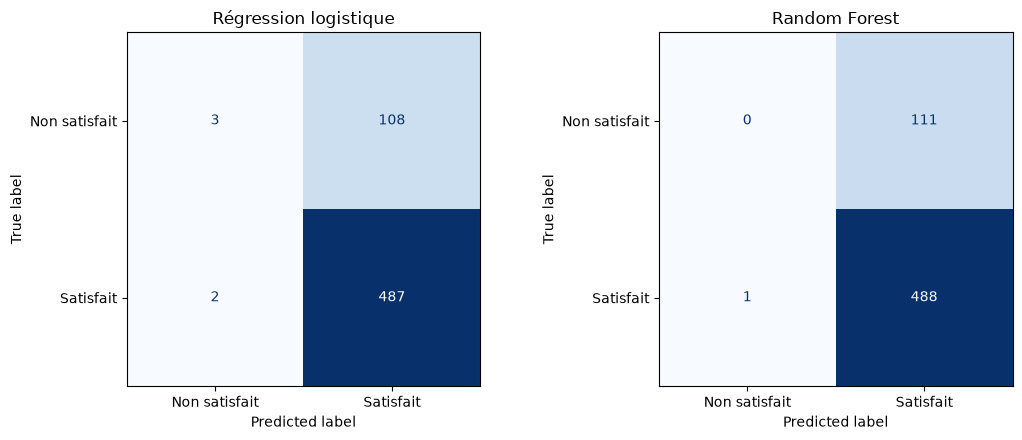

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, modele, nom in zip(axes, [modele_logit, modele_rf_clf], ['Régression logistique', 'Random Forest']):
    y_pred = modele.predict(X_test_c)
    cm = confusion_matrix(y_test_c, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Non satisfait', 'Satisfait']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nom)
plt.tight_layout()
plt.show()

### Importance des variables (Random Forest)

C:\Users\A. Katy Gracia EKOUE\AppData\Local\Temp\ipykernel_9680\45801268.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_clf_df, x='importance', y='variable', palette='mako')


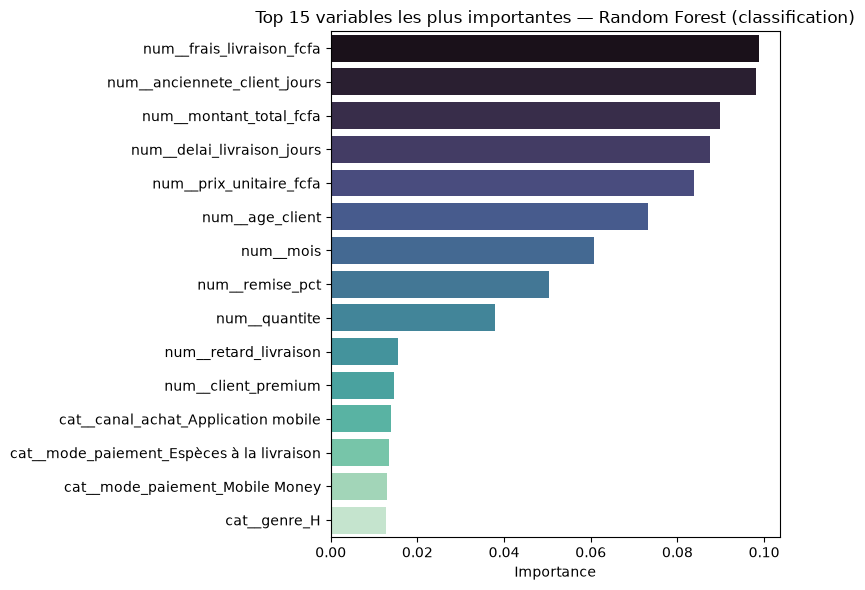

In [80]:
noms_variables_c = modele_rf_clf.named_steps['preprocessing'].get_feature_names_out()
importances_c = modele_rf_clf.named_steps['classifier'].feature_importances_

imp_clf_df = pd.DataFrame({'variable': noms_variables_c, 'importance': importances_c}) \
                .sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=imp_clf_df, x='importance', y='variable', palette='mako')
plt.title("Top 15 variables les plus importantes — Random Forest (classification)")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Interprétation (classification) :**

- Les deux modèles affichent une accuracy proche de 82 % (régression logistique : 0,817 · Random Forest : 0,813), ce qui **semble** bon - mais c'est trompeur : **81,5 % des clients sont déjà satisfaits dans les données** (`df['satisfait'].value_counts(normalize=True)`). Un modèle qui prédirait « satisfait » à chaque fois, sans rien apprendre, obtiendrait déjà ~81,5 % d'accuracy. Nos modèles ne font donc **quasiment pas mieux qu'une règle naïve**.
- Le vrai problème apparaît dans le détail (matrice de confusion / classification_report) : le rappel sur la classe « Non satisfait » n'est que de **3 %** - le modèle rate quasiment tous les clients insatisfaits, alors que c'est précisément ce que la direction veut détecter *("agir avant qu'il ne soit déçu")*. Un rappel de 99,6-99,8 % sur la classe « Satisfait » confirme que le modèle prédit presque toujours la classe majoritaire.
- Les variables les plus influentes selon le Random Forest sont les **frais de livraison**, l'**ancienneté client**, le **montant de la commande** et le **délai de livraison** — cohérent avec le constat de l'EDA (le retard de livraison dégrade la satisfaction), mais leur pouvoir prédictif reste insuffisant pour bien séparer les deux classes.
- **Recommandation méthodologique :** ce déséquilibre de classes (81,5 % / 18,5 %) doit être traité avant de déployer un tel modèle - par exemple avec `class_weight='balanced'`, du sur-échantillonnage (SMOTE) de la classe minoritaire, ou en changeant le seuil de décision par défaut (0,5) pour privilégier le rappel sur « Non satisfait », quitte à accepter plus de faux positifs. En l'état, ce modèle **n'est pas encore fiable pour un déploiement opérationnel** de détection proactive de l'insatisfaction.

## Partie D - Modélisation : Clustering (segmentation client)

**Question métier (3) :** peut-on regrouper les clients en profils homogènes pour personnaliser les offres ?

Il n'y a pas de cible ici (apprentissage **non supervisé**). Comme un même client peut passer plusieurs commandes, la segmentation a plus de sens **au niveau client** qu'au niveau commande : on agrège donc le dataset par `id_client` pour construire un profil comportemental de chacun (nombre de commandes, panier moyen, ancienneté, taux de satisfaction, taux de retour...).

In [81]:
df_client = df.groupby('id_client').agg(
    nb_commandes=('id_commande', 'count'),
    montant_moyen=('montant_total_fcfa', 'mean'),
    montant_total_cumule=('montant_total_fcfa', 'sum'),
    age_client=('age_client', 'first'),
    anciennete_client_jours=('anciennete_client_jours', 'max'),
    client_premium=('client_premium', 'max'),
    taux_satisfaction=('satisfait', 'mean'),
    taux_retour=('retour_produit', 'mean'),
    delai_livraison_moyen=('delai_livraison_jours', 'mean')
).reset_index()

print(f"{df_client.shape[0]} clients uniques profilés")
df_client.head()

1445 clients uniques profilés


,id_client,nb_commandes,montant_moyen,montant_total_cumule,age_client,anciennete_client_jours,client_premium,taux_satisfaction,taux_retour,delai_livraison_moyen
0,CLI10000,1,30553.000000,30553,32.0,66.0,0,1.000000,1.0,4.700000
1,CLI10001,2,185257.500000,370515,39.0,1096.0,1,1.000000,0.0,4.750000
2,CLI10002,1,10454.000000,10454,41.0,771.0,0,1.000000,0.0,3.300000
3,CLI10003,3,61018.666667,183056,29.0,177.0,1,0.000000,0.0,2.700000
4,CLI10004,3,20117.000000,60351,18.0,277.0,1,0.666667,0.0,1.633333


### Sélection et standardisation des variables

In [82]:
features_cluster = ['nb_commandes', 'montant_moyen', 'anciennete_client_jours',
                    'age_client', 'taux_satisfaction', 'taux_retour']

X_cluster = df_client[features_cluster]

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

### Choix du nombre de clusters (méthode du coude + silhouette)

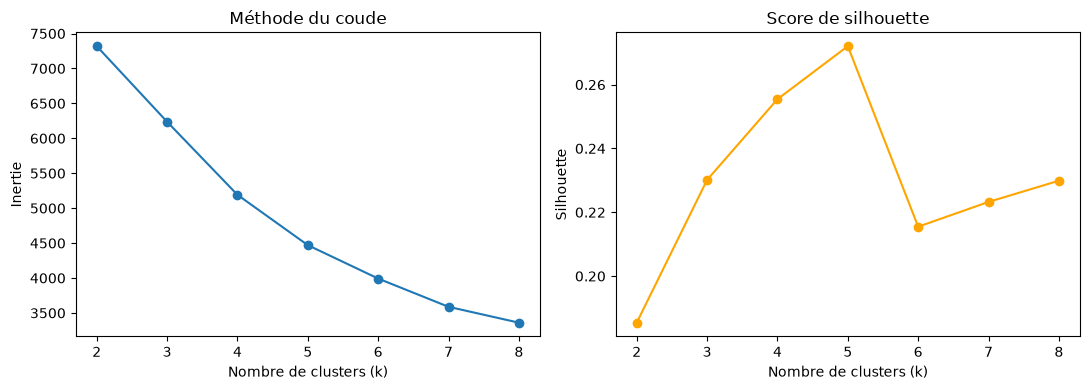

,k,inertie,silhouette
0,2,7319.294638,0.185405
1,3,6236.988525,0.230134
2,4,5191.171399,0.255434
3,5,4470.552792,0.272054
4,6,3992.122781,0.215479
5,7,3587.867886,0.223238
6,8,3360.840216,0.229892


In [83]:
inerties, silhouettes = [], []
plage_k = range(2, 9)

for k in plage_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(plage_k), inerties, marker='o')
axes[0].set_title("Méthode du coude")
axes[0].set_xlabel("Nombre de clusters (k)")
axes[0].set_ylabel("Inertie")

axes[1].plot(list(plage_k), silhouettes, marker='o', color='orange')
axes[1].set_title("Score de silhouette")
axes[1].set_xlabel("Nombre de clusters (k)")
axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

pd.DataFrame({'k': list(plage_k), 'inertie': inerties, 'silhouette': silhouettes})

On retient **k = 4** : c'est un bon compromis entre un score de silhouette élevé et un nombre de segments suffisamment riche pour être actionnable par le métier (au-delà, les gains de silhouette sont marginaux et les clusters deviennent trop fins pour être interprétables).

In [84]:
k_final = 4
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df_client['cluster'] = kmeans_final.fit_predict(X_cluster_scaled)

print(f"Score de silhouette (k={k_final}) : {silhouette_score(X_cluster_scaled, df_client['cluster']):.3f}")
df_client['cluster'].value_counts().sort_index()

Score de silhouette (k=4) : 0.255


cluster
0    689
1    436
2    234
3     86
Name: count, dtype: int64

### Profil moyen de chaque cluster

In [85]:
profil_clusters = df_client.groupby('cluster')[features_cluster + ['montant_total_cumule']].mean().round(1)
profil_clusters['nb_clients'] = df_client['cluster'].value_counts().sort_index()
profil_clusters

,nb_commandes,montant_moyen,anciennete_client_jours,age_client,taux_satisfaction,taux_retour,montant_total_cumule,nb_clients
cluster,,,,,,,,
0,1.5,60905.0,367.3,33.6,1.0,0.0,89792.8,689
1,3.3,63293.3,945.4,30.8,0.8,0.0,208854.1,436
2,1.6,63093.4,426.8,32.2,0.2,0.0,101184.1,234
3,2.0,69604.5,491.0,34.2,0.8,0.6,138217.5,86


### Visualisation des clusters (projection PCA 2D)

In [86]:
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(X_cluster_scaled)
df_client['pca_1'] = coords_2d[:, 0]
df_client['pca_2'] = coords_2d[:, 1]

fig = px.scatter(
    df_client, x='pca_1', y='pca_2', color=df_client['cluster'].astype(str),
    hover_data=['nb_commandes', 'montant_moyen', 'taux_satisfaction'],
    title="Segmentation client - projection PCA des 4 clusters",
    labels={'color': 'Cluster'}
)
fig.show()

**Interprétation (clustering) :**

La segmentation en 4 clusters (silhouette ≈ voir score ci-dessus) fait émerger des profils clients bien différenciés :

| Cluster | Taille | Profil |
|---|---|---|
| **0** | 689 clients (47,7 %) | Clients plutôt récents (ancienneté ~367 j), peu de commandes (1,5 en moyenne), **satisfaction maximale (100 %)**, aucun retour. Base saine mais sous-exploitée. |
| **1** | 436 clients (30,2 %) | Clients les plus **anciens et les plus fidèles** (ancienneté ~945 j, 3,3 commandes en moyenne), satisfaction correcte (80 %), et **chiffre d'affaires cumulé le plus élevé** (~208 854 FCFA/client). Le cœur de valeur de TogoShop. |
| **2** | 234 clients (16,2 %) | Comportement d'achat normal mais **satisfaction très faible (20 %)** - un segment à risque de churn silencieux, à investiguer en priorité (probablement lié aux délais de livraison, cf. Partie A). |
| **3** | 86 clients (6,0 %) | Panier moyen le plus élevé (~69 604 FCFA) mais **taux de retour produit très élevé (60 %)** - signal de problème qualité/adéquation produit sur ce segment. |

**Recommandations métier par segment :**
- **Cluster 0 (nouveaux clients satisfaits)** → programme de bienvenue / relance pour transformer le premier achat en récurrence (email J+15, coupon deuxième commande).
- **Cluster 1 (clients fidèles à forte valeur)** → programme VIP, avantages prioritaires (livraison, support dédié) pour sécuriser cette base qui génère le plus de revenu.
- **Cluster 2 (clients à risque de churn)** → campagne de reconquête ciblée, enquête de satisfaction proactive, vérifier en priorité les délais de livraison sur ce segment.
- **Cluster 3 (fort taux de retour)** → audit qualité sur les produits/catégories concernées, revoir les fiches produits (tailles, descriptions) pour réduire les retours malgré un panier attractif.

## Partie E - Synthèse des résultats et recommandations métier

### 1. Comprendre : qu'est-ce qui influence le montant d'une commande ?

La catégorie de produit (Téléphonie, Électronique en tête), l'ancienneté du client, les frais et le délai de livraison sont les facteurs les plus associés au montant d'une commande. Le meilleur modèle (régression linéaire) explique environ **31 % de la variance** du montant - une part significative mais qui laisse deviner que d'autres facteurs non mesurés ici (produit précis, promotions ponctuelles) jouent aussi un rôle important.

**Recommandation :** concentrer les campagnes marketing sur les catégories à forte valeur, et développer un programme de fidélité valorisant l'ancienneté client.

### 2. Anticiper la satisfaction : peut-on prédire si un client sera satisfait ?

Les modèles testés (régression logistique, Random Forest) atteignent ~82 % d'accuracy, mais **ce chiffre est trompeur** : il ne fait quasiment pas mieux qu'une prédiction naïve « toujours satisfait » (81,5 % des cas dans les données). Le rappel sur les clients insatisfaits n'est que de 3 % - les modèles actuels **ne permettent pas** de détecter de façon fiable les clients à risque d'insatisfaction.

**Recommandation :** avant tout déploiement, retraiter le déséquilibre des classes (pondération, ré-échantillonnage) et enrichir les données avec des variables de service client (réclamations, délais de réponse SAV, historique de contact) qui manquent probablement ici pour bien discriminer les deux classes.

### 3. Segmenter : peut-on regrouper les clients en profils homogènes ?

Oui : 4 segments clairs émergent - nouveaux clients satisfaits (47,7 %), clients fidèles à forte valeur (30,2 %), clients à risque de churn silencieux (16,2 %) et clients à fort taux de retour produit (6,0 %). Chacun appelle une action commerciale différenciée (détail dans la Partie D).

### Synthèse générale

TogoShop dispose d'une base de données riche mais qui, en l'état, permet surtout de bien **comprendre le passé** (EDA, segmentation) plutôt que de **prédire fiablement l'avenir** (la classification de la satisfaction reste à améliorer). Priorité recommandée : 
(1) déployer les actions de rétention par segment identifiées en Partie D, qui sont directement actionnables dès maintenant ; 
(2) enrichir la collecte de données côté service client avant de retravailler le modèle de prédiction de satisfaction ; 
(3) analyser plus finement le cluster à fort taux de retour (Partie D, cluster 3) pour un gain rapide sur la qualité produit.